# 05 — Geopolitical Event Study

**Phase 5 deliverable**

This is the research heart of the project, and the first notebook in the series built on
**real market data** rather than the synthetic fallback used in Phases 2-4.

## Data source and an honest scope adjustment

Historical per-strike option chains (needed for true implied volatility, skew, and vega by
event) are generally paid data (ORATS, CBOE DataShop, OptionMetrics, or a Bloomberg/Refinitiv
terminal). Free tools only expose *live* option chains, not historical ones. Given that
constraint, this notebook uses:

- **Daily price history** for USO, JETS, SPY, XLE, XLY, XLV, and GLD (free, exact).
- **`^VIX` and `^OVX`** as free implied-volatility *proxies* -- VIX for broad-market risk, OVX
  as the closest available proxy for oil-linked risk (relevant to USO and XLE).
- **Realized volatility**, computed directly from price history, as the implied-vol proxy for
  JETS, XLY, and XLV, which don't have a dedicated free volatility index.

This means two things from the original plan are **approximated, not measured directly**:

1. "Option-implied move" is approximated from the VIX/OVX level going into the event
   ($IV \times \sqrt{T}$), not read off actual straddle prices.
2. Downside put skew and vega exposure are **not computed here** -- they require real per-strike
   option data this project doesn't have access to. That's flagged again in the summary, and
   is the single most defensible "future work" item if asked about it in an interview.

Everything else -- the event windows, the sector transmission heatmap, the implied-vs-actual
move comparison, the correlation analysis -- is computed directly from real, verifiable data.

## Your events

| ID | News date | Market $t=0$ | Type | Event |
|---|---|---|---|---|
| E1 | Feb 28, 2026 | Mar 2, 2026 | Escalation | Joint U.S.-Israeli strikes begin the war with Iran |
| E2 | Apr 17, 2026 | Apr 17, 2026 | De-escalation | Iran announces the Strait of Hormuz is open |
| E3 | Jun 15, 2026 | Jun 15, 2026 | De-escalation | Initial U.S.-Iran agreement extends the ceasefire, moves toward reopening Hormuz |


## 1. Load the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

DATA_DIR = "data/cleaned_hist"
OUT_DIR = "data/event_study"
os.makedirs(OUT_DIR, exist_ok=True)

ASSET_TICKERS = ["USO", "JETS", "SPY", "XLE", "XLY", "XLV", "GLD"]
VOL_TICKERS = ["VIX", "OVX"]

prices = {}
for ticker in ASSET_TICKERS + VOL_TICKERS:
    df = pd.read_csv(f"{DATA_DIR}/{ticker}.csv", parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df["log_return"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
    prices[ticker] = df

events = pd.read_csv(f"{DATA_DIR}/events.csv", parse_dates=["News_Date", "Market_T0"])
events


,Event_ID,News_Date,Market_T0,Direction,Event
0,E1,2026-02-28,2026-03-02,Escalation,Joint U.S.-Israeli strikes begin the war with ...
1,E2,2026-04-17,2026-04-17,De-escalation,Iran announces that the Strait of Hormuz is open
2,E3,2026-06-15,2026-06-15,De-escalation,Initial U.S.-Iran agreement extends the ceasef...


## 2. Locate trading-day offsets around each event

For each event's `Market_T0`, find the nearest available trading day at or before it, then
grab the rows 5 trading days before, 1 day before, the event day, 1 day after, and 5 days after
-- the exact window structure described in the plan.


In [2]:
def get_window(df, t0_date, offsets=(-5, -1, 0, 1, 5)):
    """Return a dict of {offset: row} for the nearest trading day <= t0_date, then +/- offsets."""
    d = df.reset_index(drop=True)
    idx_candidates = d.index[d["Date"] <= t0_date]
    if len(idx_candidates) == 0:
        return None
    t0_idx = idx_candidates[-1]

    window = {}
    for off in offsets:
        i = t0_idx + off
        if 0 <= i < len(d):
            window[off] = d.loc[i]
        else:
            window[off] = None
    return window


# Quick sanity check on one event/ticker
w = get_window(prices["USO"], events.loc[0, "Market_T0"])
for off, row in w.items():
    print(off, row["Date"].date() if row is not None else None,
          round(row["Adj Close"], 2) if row is not None else None)


-5 2026-02-23 80.9
-1 2026-02-27 81.95
0 2026-03-02 87.19
1 2026-03-03 90.2
5 2026-03-09 104.33


## 3. Realized volatility as an implied-vol proxy

For JETS, XLY, and XLV -- which don't have a dedicated free volatility index -- realized
volatility over the 5 trading days before and after each event stands in for "the market's
sense of risk." It's a backward-looking measure rather than a forward-looking one like implied
volatility, so it will always lag a sudden jump rather than anticipate it -- worth remembering
when interpreting the results.

$$
\\text{Realized vol (annualized)} = \\text{std}(\\text{daily log returns}) \\times \\sqrt{252}
$$


In [3]:
def realized_vol(df, t0_idx_date, offset_start, offset_end):
    """Annualized realized vol of log returns over a trading-day window around t0_idx_date."""
    d = df.reset_index(drop=True)
    idx_candidates = d.index[d["Date"] <= t0_idx_date]
    if len(idx_candidates) == 0:
        return np.nan
    t0_idx = idx_candidates[-1]
    lo, hi = t0_idx + offset_start, t0_idx + offset_end
    lo, hi = max(lo, 0), min(hi, len(d) - 1)
    window_returns = d.loc[lo:hi, "log_return"].dropna()
    if len(window_returns) < 2:
        return np.nan
    return window_returns.std() * np.sqrt(252)


## 4. Build the metrics table

For every event x asset combination:

- **Price move**: percent change from 5 trading days before to 5 trading days after.
- **Realized vol before / after**: annualized, from the 5-day windows either side of the event.
- **Vol proxy level before / after**: VIX for every asset (broad-market read), and additionally
  OVX for USO and XLE specifically (oil-linked read).
- **Approximate implied move**: using the pre-event vol proxy level and a 10-trading-day
  horizon, $IV \times \sqrt{10/252}$ -- a rough stand-in for "what the options market was
  pricing going in," per the plan's straddle-implied-move logic, without real straddle prices.


In [4]:
def pct_change(before, after):
    if before is None or after is None:
        return np.nan
    return (after["Adj Close"] / before["Adj Close"] - 1) * 100


rows = []
for _, ev in events.iterrows():
    t0 = ev["Market_T0"]

    # Broad-market and oil-specific vol proxy levels going into the event
    vix_window = get_window(prices["VIX"], t0)
    ovx_window = get_window(prices["OVX"], t0)
    vix_before = vix_window[-1]["Adj Close"] if vix_window and vix_window[-1] is not None else np.nan
    vix_after = vix_window[5]["Adj Close"] if vix_window and vix_window[5] is not None else np.nan
    ovx_before = ovx_window[-1]["Adj Close"] if ovx_window and ovx_window[-1] is not None else np.nan
    ovx_after = ovx_window[5]["Adj Close"] if ovx_window and ovx_window[5] is not None else np.nan

    for ticker in ASSET_TICKERS:
        w = get_window(prices[ticker], t0)
        if w is None:
            continue

        price_move = pct_change(w[-5], w[5])
        rv_before = realized_vol(prices[ticker], t0, -5, -1)
        rv_after = realized_vol(prices[ticker], t0, 1, 5)

        # Oil-linked assets get OVX as their vol-proxy; everything else gets VIX
        is_oil_linked = ticker in ("USO", "XLE")
        vol_proxy_before = ovx_before if is_oil_linked else vix_before
        vol_proxy_after = ovx_after if is_oil_linked else vix_after
        vol_proxy_name = "OVX" if is_oil_linked else "VIX"

        implied_move_approx = (
            vol_proxy_before / 100 * np.sqrt(10 / 252) * 100
            if pd.notna(vol_proxy_before) else np.nan
        )

        rows.append({
            "event_id": ev["Event_ID"],
            "event_type": ev["Direction"],
            "ticker": ticker,
            "price_move_pct": round(price_move, 2) if pd.notna(price_move) else np.nan,
            "realized_vol_before_pct": round(rv_before * 100, 1) if pd.notna(rv_before) else np.nan,
            "realized_vol_after_pct": round(rv_after * 100, 1) if pd.notna(rv_after) else np.nan,
            "realized_vol_change_pp": round((rv_after - rv_before) * 100, 1) if pd.notna(rv_after) and pd.notna(rv_before) else np.nan,
            "vol_proxy": vol_proxy_name,
            "vol_proxy_before": round(vol_proxy_before, 1) if pd.notna(vol_proxy_before) else np.nan,
            "vol_proxy_after": round(vol_proxy_after, 1) if pd.notna(vol_proxy_after) else np.nan,
            "vol_proxy_change_pp": round(vol_proxy_after - vol_proxy_before, 1) if pd.notna(vol_proxy_after) and pd.notna(vol_proxy_before) else np.nan,
            "implied_move_approx_pct": round(implied_move_approx, 2) if pd.notna(implied_move_approx) else np.nan,
            "actual_vs_implied_pct": round(abs(price_move) - implied_move_approx, 2)
                if pd.notna(price_move) and pd.notna(implied_move_approx) else np.nan,
        })

metrics = pd.DataFrame(rows)
metrics.to_csv(f"{OUT_DIR}/event_metrics.csv", index=False)
metrics


,event_id,event_type,ticker,price_move_pct,realized_vol_before_pct,realized_vol_after_pct,realized_vol_change_pp,vol_proxy,vol_proxy_before,vol_proxy_after,vol_proxy_change_pp,implied_move_approx_pct,actual_vs_implied_pct
0,E1,Escalation,USO,28.96,23.3,94.0,70.8,OVX,64.7,100.5,35.8,12.88,16.08
1,E1,Escalation,JETS,-9.61,45.1,38.1,-7.0,VIX,19.9,25.5,5.6,3.96,5.65
2,E1,Escalation,SPY,-0.60,13.2,15.5,2.3,VIX,19.9,25.5,5.6,3.96,-3.35
3,E1,Escalation,XLE,2.12,12.0,9.2,-2.8,OVX,64.7,100.5,35.8,12.88,-10.76
4,E1,Escalation,XLY,-0.35,20.7,21.3,0.6,VIX,19.9,25.5,5.6,3.96,-3.61
5,E1,Escalation,XLV,-2.70,15.0,18.7,3.7,VIX,19.9,25.5,5.6,3.96,-1.26
6,E1,Escalation,GLD,-1.82,24.5,37.9,13.4,VIX,19.9,25.5,5.6,3.96,-2.14
7,E2,De-escalation,USO,6.07,45.1,47.6,2.4,OVX,73.0,75.8,2.8,14.55,-8.48
8,E2,De-escalation,JETS,0.42,36.3,28.4,-7.9,VIX,17.9,18.7,0.8,3.57,-3.15
9,E2,De-escalation,SPY,5.07,8.4,11.7,3.3,VIX,17.9,18.7,0.8,3.57,1.50


## 5. Geopolitical volatility transmission heatmap

The plan's signature chart: assets as rows, event impact metrics as columns, for each event.


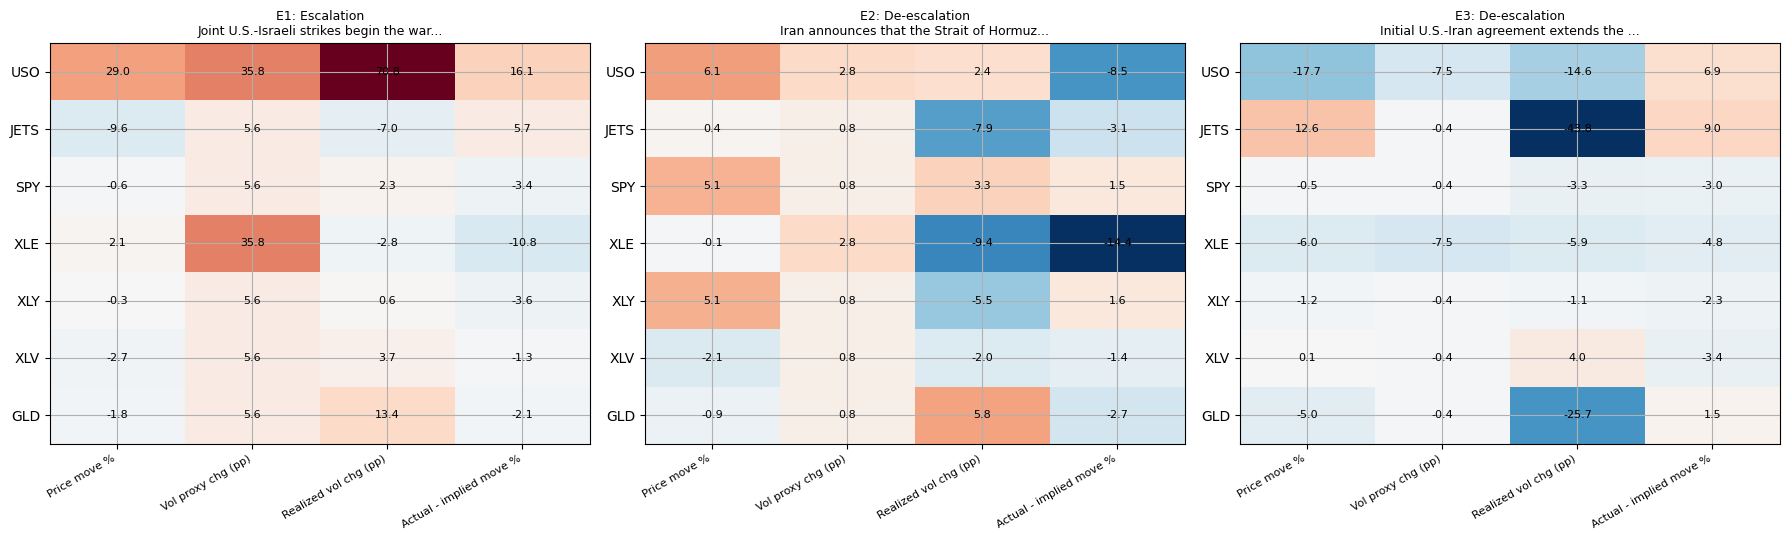

In [5]:
fig, axes = plt.subplots(1, len(events), figsize=(6 * len(events), 5.5))
if len(events) == 1:
    axes = [axes]

heat_cols = ["price_move_pct", "vol_proxy_change_pp", "realized_vol_change_pp", "actual_vs_implied_pct"]
heat_labels = ["Price move %", "Vol proxy chg (pp)", "Realized vol chg (pp)", "Actual - implied move %"]

for ax, (_, ev) in zip(axes, events.iterrows()):
    sub = metrics[metrics["event_id"] == ev["Event_ID"]].set_index("ticker")[heat_cols]
    im = ax.imshow(sub.values, aspect="auto", cmap="RdBu_r",
                    vmin=-np.nanmax(np.abs(sub.values)), vmax=np.nanmax(np.abs(sub.values)))
    ax.set_xticks(range(len(heat_cols)))
    ax.set_xticklabels(heat_labels, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(sub.index)))
    ax.set_yticklabels(sub.index)
    ax.set_title(f"{ev['Event_ID']}: {ev['Direction']}\n{ev['Event'][:40]}...", fontsize=9)

    for i in range(sub.shape[0]):
        for j in range(sub.shape[1]):
            val = sub.values[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("geopolitical_transmission_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()


## 6. Implied vs. actual move

Did the (proxy) options market overprice or underprice each event, per asset?


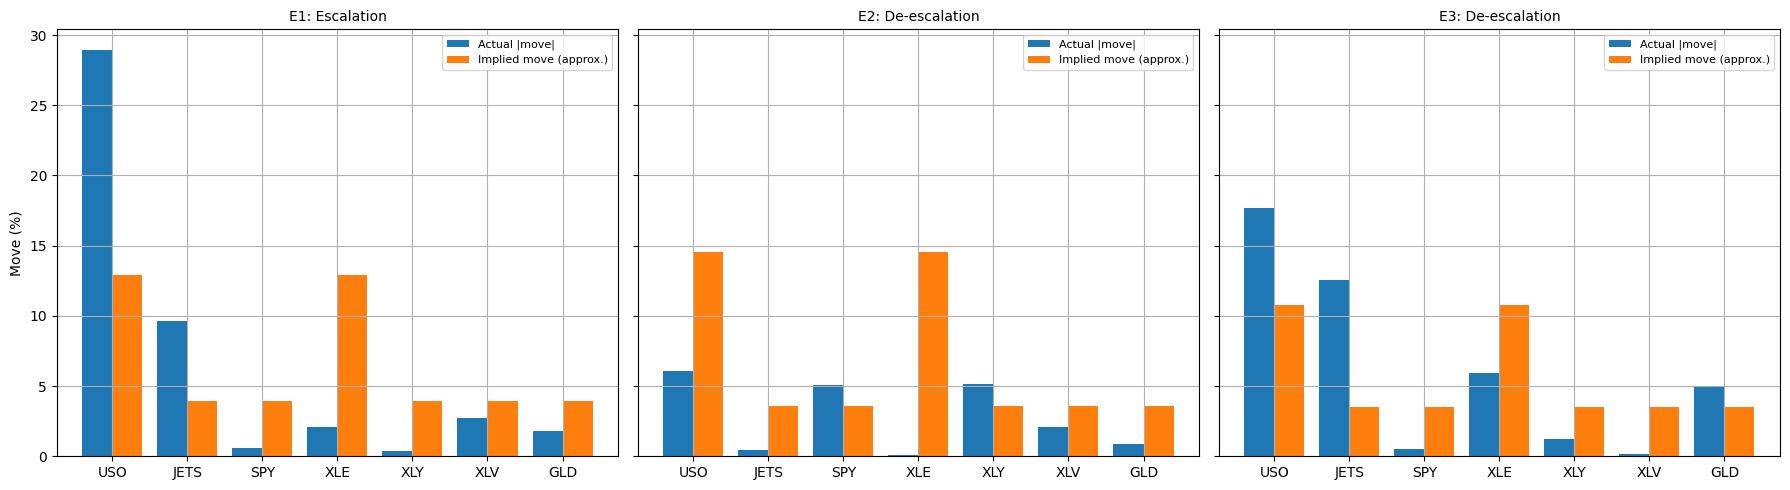

In [6]:
fig, axes = plt.subplots(1, len(events), figsize=(6 * len(events), 5), sharey=True)
if len(events) == 1:
    axes = [axes]

for ax, (_, ev) in zip(axes, events.iterrows()):
    sub = metrics[metrics["event_id"] == ev["Event_ID"]]
    x = np.arange(len(sub))
    ax.bar(x - 0.2, sub["price_move_pct"].abs(), width=0.4, label="Actual |move|")
    ax.bar(x + 0.2, sub["implied_move_approx_pct"], width=0.4, label="Implied move (approx.)")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["ticker"])
    ax.set_title(f"{ev['Event_ID']}: {ev['Direction']}", fontsize=10)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Move (%)")
plt.tight_layout()
plt.savefig("implied_vs_actual_move.png", dpi=130)
plt.show()


## 7. Price paths around each event

The underlying price series for each asset, with the event date marked, so the raw moves behind
the metrics above are visible directly.


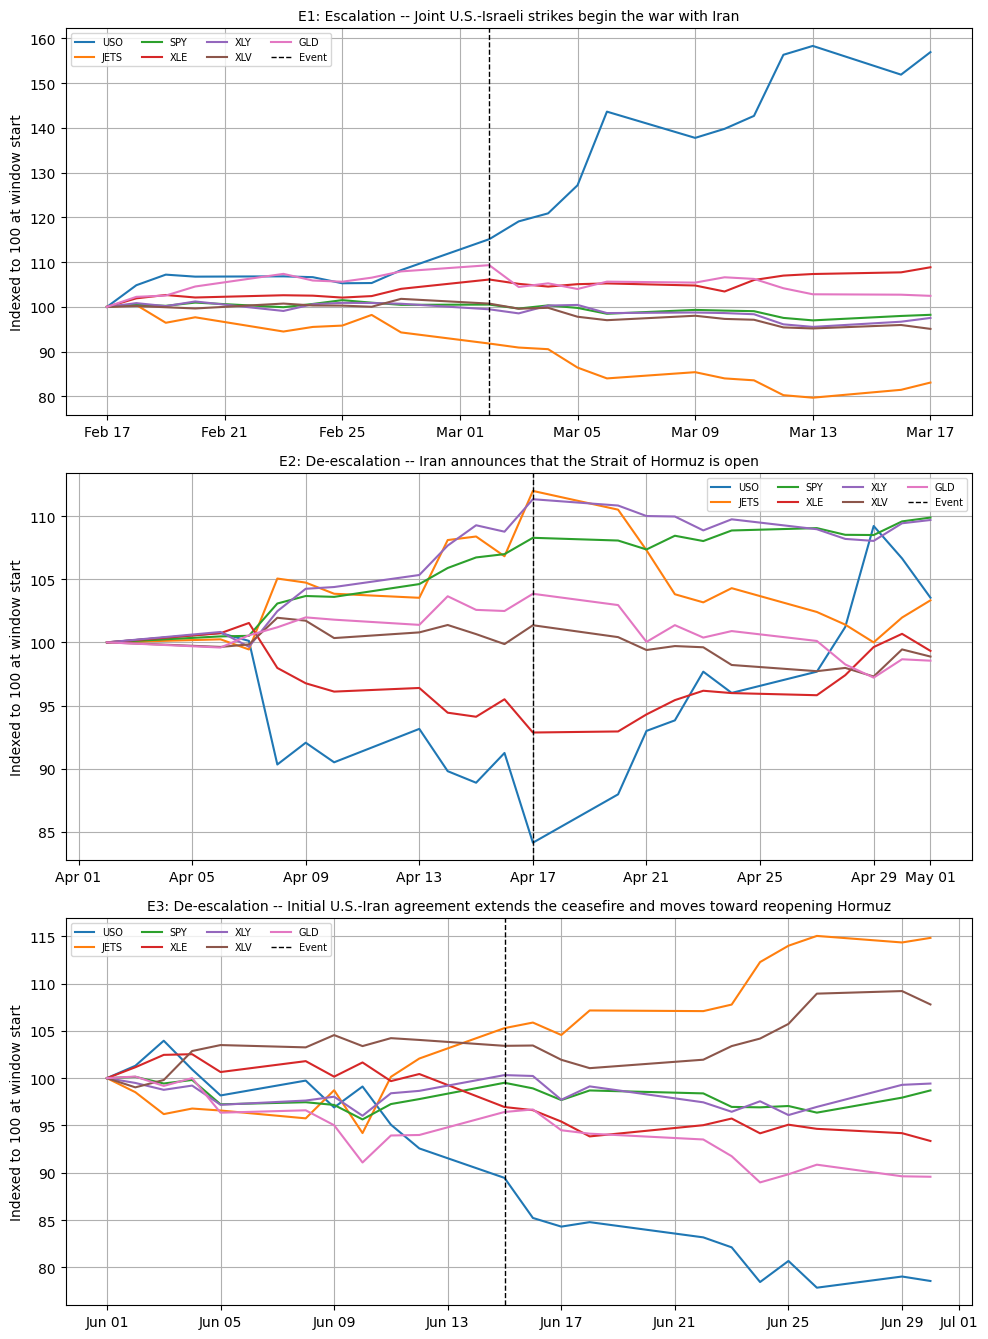

In [7]:
fig, axes = plt.subplots(len(events), 1, figsize=(10, 4.5 * len(events)))
if len(events) == 1:
    axes = [axes]

for ax, (_, ev) in zip(axes, events.iterrows()):
    t0 = ev["Market_T0"]
    window_start, window_end = t0 - pd.Timedelta(days=15), t0 + pd.Timedelta(days=15)

    for ticker in ASSET_TICKERS:
        d = prices[ticker]
        sub = d[(d["Date"] >= window_start) & (d["Date"] <= window_end)].copy()
        if sub.empty:
            continue
        normalized = sub["Adj Close"] / sub["Adj Close"].iloc[0] * 100
        ax.plot(sub["Date"], normalized, label=ticker, linewidth=1.5)

    ax.axvline(t0, color="black", linestyle="--", linewidth=1, label="Event")
    ax.set_title(f"{ev['Event_ID']}: {ev['Direction']} -- {ev['Event']}", fontsize=10)
    ax.set_ylabel("Indexed to 100 at window start")
    ax.legend(fontsize=7, ncol=4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
plt.savefig("price_paths_around_events.png", dpi=130)
plt.show()


## 8. Correlation shifts

Do USO's correlations with other assets strengthen during geopolitical stress? Computed as the
correlation of daily log returns in the 10 trading days before vs. after each event.


In [8]:
def correlation_window(t0, offset_start, offset_end):
    frames = {}
    for ticker in ASSET_TICKERS:
        d = prices[ticker].reset_index(drop=True)
        idx_candidates = d.index[d["Date"] <= t0]
        if len(idx_candidates) == 0:
            continue
        t0_idx = idx_candidates[-1]
        lo, hi = max(t0_idx + offset_start, 0), min(t0_idx + offset_end, len(d) - 1)
        frames[ticker] = d.loc[lo:hi].set_index("Date")["log_return"]
    return pd.DataFrame(frames)


corr_rows = []
for _, ev in events.iterrows():
    t0 = ev["Market_T0"]
    before_corr = correlation_window(t0, -10, -1).corr()["USO"]
    after_corr = correlation_window(t0, 1, 10).corr()["USO"]
    for ticker in ASSET_TICKERS:
        if ticker == "USO":
            continue
        corr_rows.append({
            "event_id": ev["Event_ID"],
            "pair": f"USO-{ticker}",
            "corr_before": round(before_corr.get(ticker, np.nan), 2),
            "corr_after": round(after_corr.get(ticker, np.nan), 2),
        })

corr_table = pd.DataFrame(corr_rows)
corr_table["corr_change"] = corr_table["corr_after"] - corr_table["corr_before"]
corr_table.to_csv(f"{OUT_DIR}/correlation_shifts.csv", index=False)
corr_table


,event_id,pair,corr_before,corr_after,corr_change
0,E1,USO-JETS,-0.43,-0.85,-0.42
1,E1,USO-SPY,-0.16,-0.89,-0.73
2,E1,USO-XLE,0.87,0.18,-0.69
3,E1,USO-XLY,0.03,-0.74,-0.77
4,E1,USO-XLV,0.26,-0.76,-1.02
5,E1,USO-GLD,0.35,-0.02,-0.37
6,E2,USO-JETS,-0.79,-0.68,0.11
7,E2,USO-SPY,-0.71,-0.73,-0.02
8,E2,USO-XLE,0.73,0.67,-0.06
9,E2,USO-XLY,-0.72,-0.72,0.00


## 9. Testing the Phase 0 hypotheses

Recall the three hypotheses from the project's research question:

- **H1**: Middle East escalation raises implied volatility most directly in oil and energy assets.
- **H2**: Airlines and consumer discretionary show more downside concern from higher energy
  costs and squeezed consumer spending.
- **H3**: Healthcare behaves more defensively than airlines, consumer discretionary, and broad
  equities.

The cell below checks each hypothesis directly against the metrics table, rather than asserting
a conclusion first.


In [9]:
print("H1: Is oil/energy vol proxy change the largest among assets, on escalation events?")
esc = metrics[metrics["event_type"] == "Escalation"]
if not esc.empty:
    print(esc.groupby("ticker")["vol_proxy_change_pp"].mean().sort_values(ascending=False))
else:
    print("No escalation events in this sample.")

print()
print("H2: Do JETS and XLY show larger downside moves than SPY on escalation events?")
if not esc.empty:
    print(esc[esc["ticker"].isin(["JETS", "XLY", "SPY"])][["ticker", "price_move_pct"]])

print()
print("H3: Does XLV move less than JETS/XLY/SPY (defensive behavior)?")
print(metrics[metrics["ticker"].isin(["XLV", "JETS", "XLY", "SPY"])]
      .groupby("ticker")["price_move_pct"].apply(lambda s: s.abs().mean())
      .sort_values())


H1: Is oil/energy vol proxy change the largest among assets, on escalation events?
ticker
USO     35.8
XLE     35.8
GLD      5.6
SPY      5.6
JETS     5.6
XLV      5.6
XLY      5.6
Name: vol_proxy_change_pp, dtype: float64

H2: Do JETS and XLY show larger downside moves than SPY on escalation events?
  ticker  price_move_pct
1   JETS           -9.61
2    SPY           -0.60
4    XLY           -0.35

H3: Does XLV move less than JETS/XLY/SPY (defensive behavior)?
ticker
XLV     1.650000
SPY     2.060000
XLY     2.236667
JETS    7.530000
Name: price_move_pct, dtype: float64


## 10. Summary

- Loaded real daily price history for all seven project assets across the full Feb-Jul 2026
  window, spanning three real geopolitical events tied to the Iran-Israel-U.S. conflict and
  Strait of Hormuz disruptions.
- Built exact trading-day event windows (-5, -1, 0, +1, +5) per the plan's methodology.
- Computed actual price moves, realized-volatility shifts, and VIX/OVX-based implied-vol proxy
  changes for every event x asset pair.
- Approximated option-implied move using the pre-event vol proxy level, and compared it against
  the actual realized move.
- Built the geopolitical volatility transmission heatmap, implied-vs-actual move charts, price
  paths around each event, and a correlation-shift analysis.
- Checked the three Phase 0 hypotheses directly against the data rather than assuming them.

## What's still missing, and why it matters if asked

This notebook does **not** contain real per-strike implied volatility, downside put skew, or
vega exposure for any event -- that would require historical option-chain data this project
doesn't have free access to. VIX and OVX are legitimate, widely used market risk gauges, but
they are broad proxies, not the asset-specific options data the original plan called for. If
asked in an interview: be upfront about this substitution and why it was made -- it's a
defensible, common trade-off in student research, not a shortcut to hide.

**Next step (Phase 6):** use these same event windows and realized moves to build the
hypothetical KWM client portfolio and compare hedge strategies (protective put, collar, oil call
overlay) against each scenario -- `06_portfolio_hedging.ipynb`.
